# **Background and Foreground Subtraction**

#### **Objectives:**
1. Background Subtraction with Gaussian Mixture-based Background/Foreground Segmentation Algorithm
2. Improved adaptive Gausian mixture model for background subtraction


> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

**Taken fron the OpenCV Docs**



Background subtraction (BS) is a common and widely used technique for generating a foreground mask (namely, a binary image containing the pixels belonging to moving objects in the scene) by using static cameras.

As the name suggests, BS calculates the foreground mask performing a subtraction between the current frame and a background model, containing the static part of the scene or, more in general, everything that can be considered as background given the characteristics of the observed scene.

![](https://docs.opencv.org/3.4/Background_Subtraction_Tutorial_Scheme.png)

Background modeling consists of two main steps:

1. Background Initialization;
2. Background Update.

In the first step, an initial model of the background is computed, while in the second step that model is updated in order to adapt to possible changes in the scene.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

# **What is Background Subtraction?**

Using the computer vision approach of background subtraction, we aim to separate the "moving" foreground from the backdrop. Think of cars driving on a street, or people strolling on a sidewalk. 

The idea of keeping the station's pixels and deleting the ones that were changing seems straightforward. But factors like shifting lighting, shadows, and other elements might complicate matters. 

For this reason, a number of algorithms were introduced. Below, we will have a look at two algorithms from the **bgsegm** module.

### **Gaussian Mixture-based Background/Foreground Segmentation Algorithm**

We provide in this study a background subtraction (BGS) method that uses color and depth information, and is based on the Gaussian mixture models. We employed the Gaussian distribution-based probabilistic model to combine color and depth information. Specifically, we concentrated on resolving the color camouflage issue and depth denoising. A new dataset comprising normal, color and depth camouflage scenarios was created in order to assess our approach. Color, depth, and ground truth image sequences are included in the dataset files. We evaluated the precision, recall, and F-measure of the presented using these files in comparison to the traditional color-based BGS methods. Our approach consequently performed the best. As a result, as pre-processing in high-level image processing stages, this technique will aid in the robust detection of regions of interest.


Link to Paper - https://www.researchgate.net/publication/283026260_Background_subtraction_based_on_Gaussian_mixture_models_using_color_and_depth_information

*(The abstract above is copied from the original course material and describes a color+depth camouflage-detection paper that doesn't quite match what the code below does — kept as-is per this repo's no-deletions policy. Here's what `MOG2` actually does:)*

**The core idea:** instead of one "background" value per pixel, keep a small *mixture of Gaussians* — a handful of (mean, variance, weight) triples — per pixel, built up from recent history. A road pixel might have one Gaussian centered on "usual gray asphalt" with high weight, and maybe a second centered on "gray in shadow" with lower weight. A new frame's pixel value is compared against these existing Gaussians: if it falls within a few standard deviations of a high-weight one, it's background (add it to that Gaussian's running stats — the model adapts to slow changes like a cloud passing over). If it doesn't match *any* of them, it's flagged foreground — that's a walking person, briefly.

Because it's learned per-pixel from history rather than fixed once, this handles background that isn't perfectly static — swaying leaves, flickering light — far better than "subtract the first frame" would. `KNN` (used a couple of cells down) is the same overall idea with a different (non-parametric, nearest-neighbor-based) way of deciding whether a new pixel matches recent history.

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


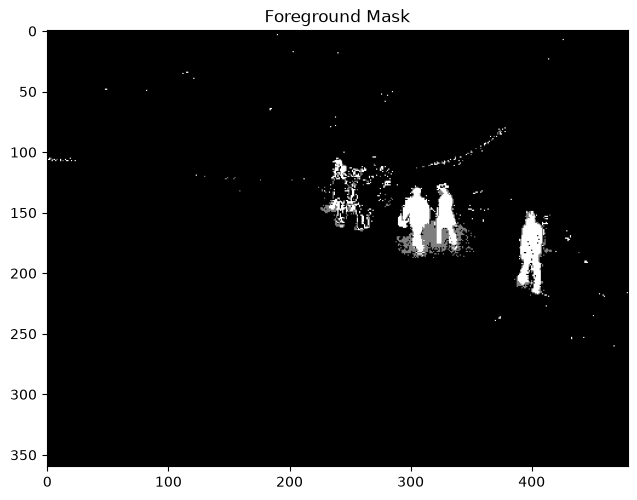

In [2]:
cap = cv2.VideoCapture('./assets/videos/walking.avi')

# Get the height and width of the frame (required to be an interger)
w = int(cap.get(3)) 
h = int(cap.get(4))

# Define the codec and create VideoWriter object. The output is stored in '*.mp4' file.
out = cv2.VideoWriter('walking_output_GM.mp4', cv2.VideoWriter_fourcc('M','P', '4','V'), 30, (w, h))

# Initlaize background subtractor
foreground_background = cv2.createBackgroundSubtractorMOG2()

# Loop once video is successfully loaded
while True:
    
    ret, frame = cap.read()

    if ret: 
      # Apply background subtractor to get our foreground mask
      foreground_mask = foreground_background.apply(frame)
      out.write(cv2.cvtColor(foreground_mask, cv2.COLOR_GRAY2BGR))  # writer needs 3 channels
      # imshow("Foreground Mask", foreground_mask)
    else:
      imshow("Foreground Mask", foreground_mask)
      break

cap.release()
out.release()

In [3]:
!ffmpeg -y -i walking_output_GM.mp4 -c:v libx264 -pix_fmt yuv420p walking_output_GM_h264.mp4 -loglevel error

MOG2 foreground mask:


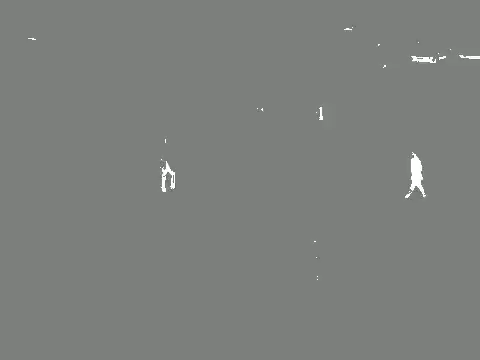

In [4]:
from nb_utils import embed_video, video_to_gif, show_gif

_gif = video_to_gif('walking_output_GM_h264.mp4', 'walking_output_GM.gif', fps=10, resize_width=480)
print('MOG2 foreground mask:')
show_gif(_gif)      # renders inline everywhere, incl. a static GitHub preview
embed_video('walking_output_GM_h264.mp4')  # a real, scrubbable player in a live notebook

### **Let's try the Improved adaptive Gausian mixture model for background subtraction**

Background subtraction is a common computer vision task. We analyze the usual pixel-level approach. We develop an efficient adaptive algorithm using Gaussian mixture probability density. Recursive equations are used to constantly update the parameters and but also to simultaneously select the appropriate number of components for each pixel.

https://www.researchgate.net/publication/4090386_Improved_Adaptive_Gaussian_Mixture_Model_for_Background_Subtraction

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


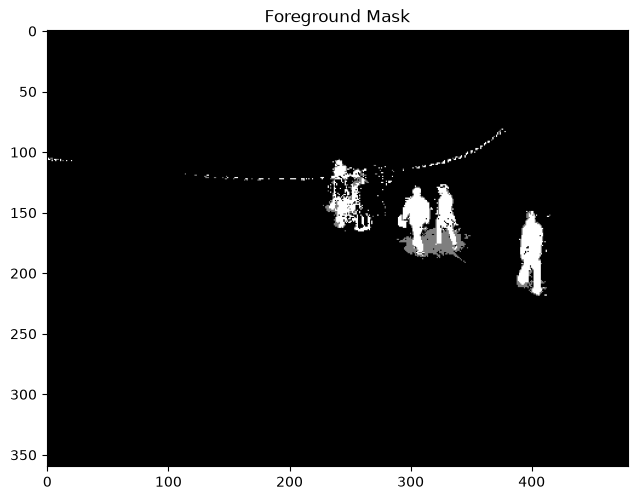

In [5]:
cap = cv2.VideoCapture('./assets/videos/walking.avi')

# Get the height and width of the frame (required to be an interfer)
w = int(cap.get(3))
h = int(cap.get(4))

# Define the codec and create VideoWriter object.The output is stored in 'output.mp4' file.
out = cv2.VideoWriter('walking_output_AGMM.mp4', cv2.VideoWriter_fourcc('M','P','4','V'), 30, (w, h))

# Initlaize background subtractor
foreground_background = cv2.createBackgroundSubtractorKNN()

# Loop once video is successfully loaded
while True:
    
    ret, frame = cap.read()
    if ret: 
      # Apply background subtractor to get our foreground mask
      foreground_mask = foreground_background.apply(frame)
      out.write(cv2.cvtColor(foreground_mask, cv2.COLOR_GRAY2BGR))  # writer needs 3 channels
      # imshow("Foreground Mask", foreground_mask)
    else:
      imshow("Foreground Mask", foreground_mask)
      break

cap.release()
out.release()

In [6]:
!ffmpeg -y -i walking_output_AGMM.mp4 -c:v libx264 -pix_fmt yuv420p walking_output_AGMM_h264.mp4 -loglevel error

KNN-based foreground mask:


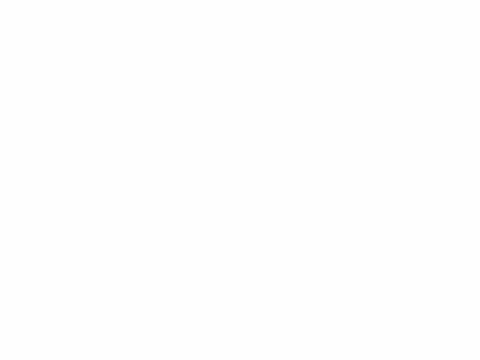

In [7]:
from nb_utils import embed_video, video_to_gif, show_gif

_gif = video_to_gif('walking_output_AGMM_h264.mp4', 'walking_output_AGMM.gif', fps=10, resize_width=480)
print('KNN-based foreground mask:')
show_gif(_gif)      # renders inline everywhere, incl. a static GitHub preview
embed_video('walking_output_AGMM_h264.mp4')  # a real, scrubbable player in a live notebook

## **Foreground Subtraction**

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


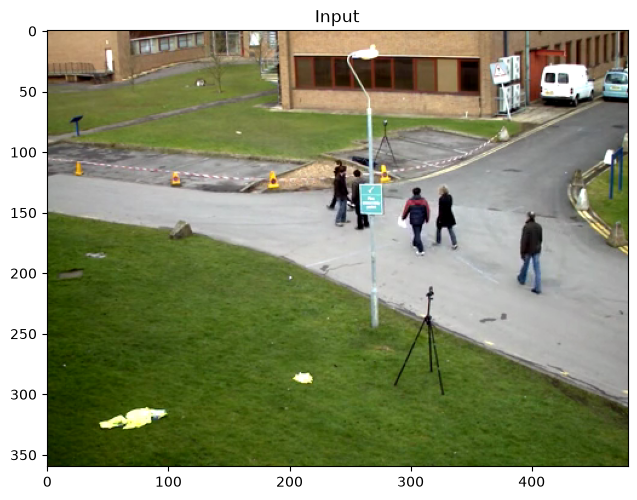

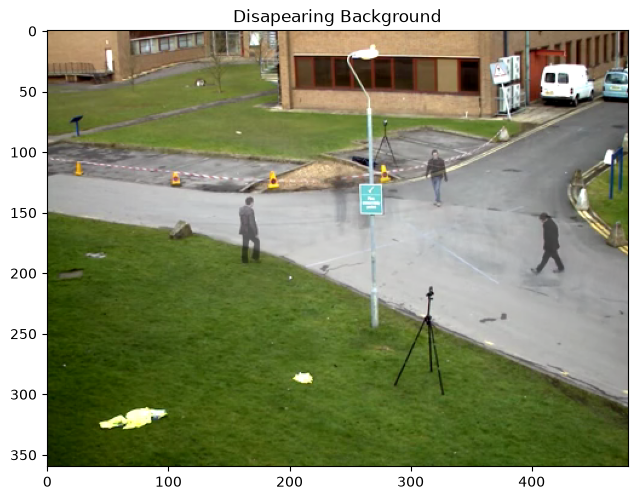

In [8]:
cap = cv2.VideoCapture('./assets/videos/walking.avi')

# Get the height and width of the frame (required to be an interfer)
w = int(cap.get(3))
h = int(cap.get(4))

# Define the codec and create VideoWriter object.The output is stored in 'output.mp4' file.
out = cv2.VideoWriter('walking_output.mp4', cv2.VideoWriter_fourcc('M','P','4', 'V'), 30, (w, h))
ret, frame = cap.read()

# Create a flaot numpy array with frame values
average = np.float32(frame)

while True:
    # Get frame
    ret, frame = cap.read()

    if ret: 
      
      # 0.01 is the weight of image, play around to see how it changes
      cv2.accumulateWeighted(frame, average, 0.01)
      
      # Scales, calculates absolute values, and converts the result to 8-bit
      background = cv2.convertScaleAbs(average)

      # imshow('Input', frame)
      # imshow('Disapearing Background', background)
      out.write(background)

      last_frame = frame

    else:
      imshow('Input', last_frame)
      imshow('Disapearing Background', background)
      break

cap.release()
out.release()

In [9]:
!ffmpeg -y -i walking_output.mp4 -c:v libx264 -pix_fmt yuv420p walking_output_bg_h264.mp4 -loglevel error

Running average background model (the scene gradually forgetting the walkers):


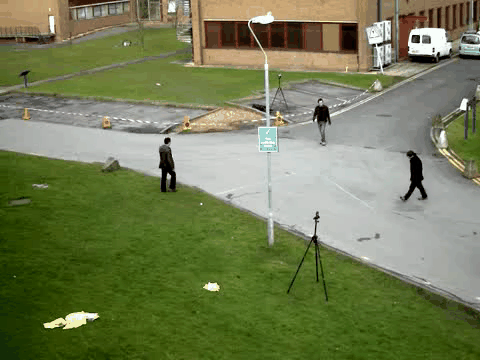

In [10]:
from nb_utils import embed_video, video_to_gif, show_gif

_gif = video_to_gif('walking_output_bg_h264.mp4', 'walking_output_bg.gif', fps=10, resize_width=480)
print('Running average background model (the scene gradually forgetting the walkers):')
show_gif(_gif)      # renders inline everywhere, incl. a static GitHub preview
embed_video('walking_output_bg_h264.mp4')  # a real, scrubbable player in a live notebook

### **Background Substraction KKN**

The parameters if you wish to veer away from the default settings:

- **history** is the number of frames used to build the statistic model of the background. The smaller the value is, the faster changes in the background will be taken into account by the model and thus be considered as background. And vice versa.
- **dist2Threshold** is a threshold to define whether a pixel is different from the background or not. The smaller the value is, the more sensitive movement detection is. And vice versa.
- **detectShadows** : If set to true, shadows will be displayed in gray on the generated mask. (Example bellow)

https://docs.opencv.org/master/de/de1/group__video__motion.html#gac9be925771f805b6fdb614ec2292006d

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


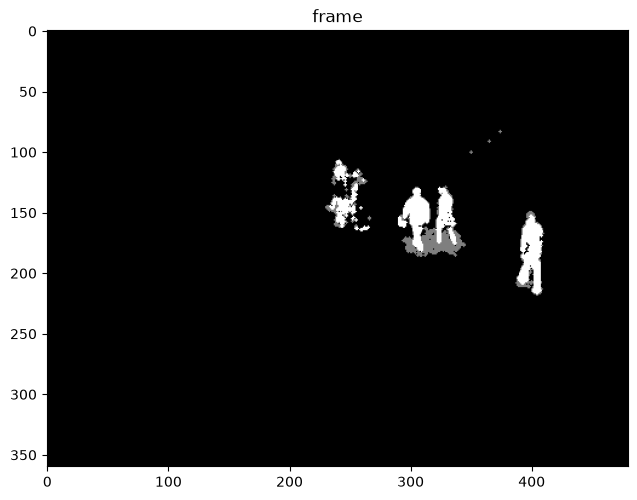

In [11]:
cap = cv2.VideoCapture('./assets/videos/walking.avi')

# Get the height and width of the frame (required to be an interfer)
w = int(cap.get(3))
h = int(cap.get(4))

# Define the codec and create VideoWriter object.The output is stored in 'output.mp4' file.
out = cv2.VideoWriter('walking_output_KNN.mp4', cv2.VideoWriter_fourcc('M','P','4', 'V'), 30, (w, h))

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
fgbg = cv2.createBackgroundSubtractorKNN()

while(1):
    ret, frame = cap.read()

    if ret:
      fgmask = fgbg.apply(frame)
      fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, kernel)

      out.write(cv2.cvtColor(fgmask, cv2.COLOR_GRAY2BGR))  # writer needs 3 channels

      # imshow('frame', fgmask)
    else:
      imshow('frame', fgmask)
      break

cap.release()
out.release()

In [12]:
!ffmpeg -y -i walking_output_KNN.mp4 -c:v libx264 -pix_fmt yuv420p walking_output_KNN_h264.mp4 -loglevel error

KNN mask after a morphological opening (cleaner than the raw KNN mask above):


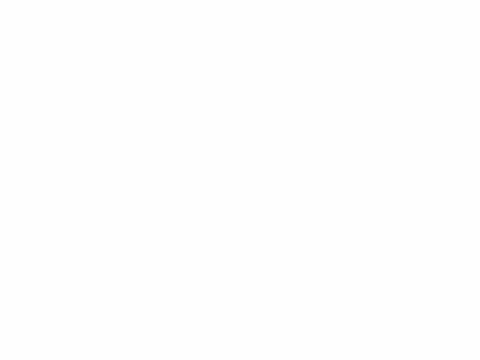

In [13]:
from nb_utils import embed_video, video_to_gif, show_gif

_gif = video_to_gif('walking_output_KNN_h264.mp4', 'walking_output_KNN.gif', fps=10, resize_width=480)
print('KNN mask after a morphological opening (cleaner than the raw KNN mask above):')
show_gif(_gif)      # renders inline everywhere, incl. a static GitHub preview
embed_video('walking_output_KNN_h264.mp4')  # a real, scrubbable player in a live notebook

### A couple of things worth poking at

- Put all four foreground masks (MOG2, AGMM/KNN, running-average, KNN+opening) side by side on the same frame index — which one best isolates the walker with the least noise?
- `detectShadows=True` (the default) paints shadows gray in the mask — threshold them out with `fg_mask == 255` to keep only confident foreground.